<a href="https://colab.research.google.com/github/busybee-123/Pollinator_Cam/blob/main/GBIF_IDs_and_Image_download_(john's_edits).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## GBIF Downloading

####Install modules

#### Imports

In [ ]:
!pip install wget
!apt-get -qq install -y re
!apt-get -qq install -y urllib.parse
!pip install pygbif
!pip install requests

import pandas as pd
import wget
import re
import tqdm
from urllib.parse import urlparse
from urllib.parse import parse_qs
from pygbif import occurrences as occ
import requests
from pygbif import species as gbifspecies
import hashlib
import numpy as np
import random
from shapely.geometry import shape
import json
from google.colab import drive
drive.mount('/content/drive')

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=0dce14762d8276a8f44ae49fdd311bf30e044753aade072e54d0497a81fb099e
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
Selecting previously unselected package re.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../re_0.1-7build1_amd64.deb ...
Unpacking re (0.1-7build1) ...
Setting up re (0.1-7build1) ...
Processing triggers for man-db (2.10.2-1) ...
E: Unable to locate package urllib.parse
E: Couldn't find any package by glob 'urllib.parse'
E: Couldn't find any package by regex 'urllib.parse'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.4 MB/s eta 0:00:00
Mounted at /content/drive


#### Functions

In [ ]:
def get_hash_ids(species_name,search_limit=50,example_limit=20):

    results = occ.search(
    taxonKey=species_keys_dict[species_name],
    basisOfRecord="HUMAN_OBSERVATION", # Changed to HUMAN OBSERVATION for realistic images
    mediatype="StillImage",
    limit=search_limit)

    tags = []
    gbif_ids = []
    k = 0

    for record in results["results"]:

        try:

            gbif_id = record["key"]

            for media in record.get("media", []):

                identifier = media["identifier"]
                md5 = hashlib.md5(
                    identifier.encode("utf-8")
                ).hexdigest()

                # The scientificName check is redundant since we already filter by taxonKey
                # Removing 'r = record.get("scientificName", [])' and the 'r in species_name' condition.

                if (k<example_limit):
                    if record['key'] not in gbif_ids:
                        k = k+1
                        tags.append(md5)
                        gbif_ids.append(record["key"])
        except:
            pass

    return tags, gbif_ids

In [ ]:
def get_gbif_link(gbifid,hashnumber):
    part = 'https://www.gbif.org/tools/zoom/simple.html?src=//api.gbif.org/v1/image/cache/occurrence/'
    return part+str(gbifid)+'/media/'+str(hashnumber)

In [ ]:
def download_image(url,name,pth_to_save,save_format='jpg'):
    try:
        parsed_url = urlparse(url)
        q = parse_qs(parsed_url.query)
        # Correctly form the image URL by prepending 'https:' to the protocol-relative path
        image_url = f"https:{q['src'][0]}"
    except KeyError:
        print(f'ERROR: No src: {url}')
    except AttributeError:
        print(f'ERROR: {url}')
    else:
        file_path = pth_to_save +'/'+ name+'.'+save_format
        wget.download(image_url, out=file_path)

###Part 0: Get Occurrences

In [ ]:
import json
from shapely.geometry import shape, Polygon

# Load your complex GeoJSON
with open('/content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/london.json') as f:
    geojson_data = json.load(f)

# Correctly access the geometry as geojson_data itself is the geometry
complex_poly = shape(geojson_data)

# Get the bounding box coordinates
minx, miny, maxx, maxy = complex_poly.bounds

# Create a Polygon from the bounding box coordinates
bounding_box_poly = Polygon([(minx, miny), (maxx, miny), (maxx, maxy), (minx, maxy), (minx, miny)])

# Print your new lightweight WKT string ready for GBIF
print(bounding_box_poly.wkt)

POLYGON ((-0.510307110218469 51.28679028785072, 0.334043875762173 51.28679028785072, 0.334043875762173 51.691875617601774, -0.510307110218469 51.691875617601774, -0.510307110218469 51.28679028785072))


To search by a higher taxonomic rank like an 'Order', you need to find the corresponding `taxonKey` for that order first. You can use `gbifspecies.name_backbone` for this, specifying the rank.

In [ ]:
# Get the taxon key for an Order (e.g., Hymenoptera)
order_name = "Hymenoptera"
order_result = gbifspecies.name_backbone(scientificName=order_name, taxonRank="ORDER", kingdom="Animalia")

try:
    order_key = order_result['usage']['key']
    print(f"Taxon Key for {order_name} (Order): {order_key}")
except KeyError:
    print(f"Could not find taxon key for order: {order_name}")
    order_key = None

Taxon Key for Hymenoptera (Order): 1457


Now you can use this `order_key` in your `occ.search` call instead of `scientificName` to filter occurrences by that entire order within your defined bounding box.

In [ ]:
from pygbif import occurrences as occ
import time # Import the time module for delays
import pandas as pd # Import pandas for data manipulation

if order_key:
    all_order_records = []
    offset = 0
    page_limit = 300  # Max records per API call
    total_records_retrieved = 0
    # Use the exact total count obtained previously
    max_total_records = 8000

    print(f"Attempting to retrieve up to {max_total_records} records...")

    while True:
        order_results = occ.search(
            taxonKey=order_key,
            geometry=bounding_box_poly.wkt,
            # Removed year filter to get relevant data
            occurrenceStatus="PRESENT",
            limit=page_limit,
            offset=offset
        )

        current_page_records = order_results['results']
        if not current_page_records:
            print("No more records to fetch or end of records reached.")
            break  # No more records to fetch

        all_order_records.extend(current_page_records)
        total_records_retrieved += len(current_page_records)

        print(f"Fetched {len(current_page_records)} records, total retrieved: {total_records_retrieved}")

        if order_results['endOfRecords'] or total_records_retrieved >= max_total_records:
            print("Reached end of records or maximum limit.")
            break

        offset += page_limit
        time.sleep(0.5) # Add a small delay to be polite to the API

    order_records = all_order_records
    print(f"Successfully retrieved {len(order_records)} records for {order_name} (Order).")

    if order_records:
        print(f"First record location: {order_records[0]['decimalLatitude']}, {order_records[0]['decimalLongitude']}")

Attempting to retrieve up to 8000 records...
Fetched 300 records, total retrieved: 300
Fetched 300 records, total retrieved: 600
Fetched 300 records, total retrieved: 900
Fetched 300 records, total retrieved: 1200
Fetched 300 records, total retrieved: 1500
Fetched 300 records, total retrieved: 1800
Fetched 300 records, total retrieved: 2100
Fetched 300 records, total retrieved: 2400
Fetched 300 records, total retrieved: 2700
Fetched 300 records, total retrieved: 3000
Fetched 300 records, total retrieved: 3300
Fetched 300 records, total retrieved: 3600
Fetched 300 records, total retrieved: 3900
Fetched 300 records, total retrieved: 4200
Fetched 300 records, total retrieved: 4500
Fetched 300 records, total retrieved: 4800
Fetched 300 records, total retrieved: 5100
Fetched 300 records, total retrieved: 5400
Fetched 300 records, total retrieved: 5700
Fetched 300 records, total retrieved: 6000
Fetched 300 records, total retrieved: 6300
Fetched 300 records, total retrieved: 6600
Fetched 300 

### Checking the total count of records

In [ ]:
# Perform a search with a small limit to get the total count efficiently
# The 'count' field in the result will give you the total number of records matching your criteria

search_for_count = occ.search(
    taxonKey=order_key,
    geometry=bounding_box_poly.wkt,
    year="2025",
    occurrenceStatus="PRESENT",
    limit=1 # We only need one record to get the total count
)

total_records_available = search_for_count['count']
print(f"Total records matching your query (without fetching all): {total_records_available}")

Total records matching your query (without fetching all): 7288


In [ ]:
unique_species = set()
unique_genera = set()
unique_families = set()

if order_records:
    for record in order_records:
        species = record.get('species')
        genus = record.get('genus')
        family = record.get('family')

        if species: unique_species.add(species)
        if genus: unique_genera.add(genus)
        if family: unique_families.add(family)

print(f"Unique Species: {unique_species}")
print(f"Unique Genera: {unique_genera}")
print(f"Unique Families: {unique_families}")

Unique Species: {'Chelostoma campanularum', 'Arge berberidis', 'Fenusa dohrnii', 'Tenthredopsis litterata', 'Hoplocampa crataegi', 'Mimesa bruxellensis', 'Cynips quercusfolii', 'Haltichella rufipes', 'Andricus lignicolus', 'Stenichneumon culpator', 'Diphyus quadripunctorius', 'Anteon gaullei', 'Hoplocampa pectoralis', 'Cerceris rybyensis', 'Nomada ruficornis', 'Lestiphorus bicinctus', 'Nomada flavoguttata', 'Monsoma pulveratum', 'Hedychrum nobile', 'Andricus foecundatrix', 'Cimbex femoratus', 'Bombus hypnorum', 'Aphelopus atratus', 'Quadrastichus vacuna', 'Apethymus filiformis', 'Virgichneumon albilineatus', 'Ethelurgus sodalis', 'Rhyssella approximator', 'Polistes biglumis', 'Psenulus pallipes', 'Technomyrmex vitiensis', 'Colletes hederae', 'Dusona remota', 'Ichneumon stramentor', 'Selandria serva', 'Otoblastus luteomarginatus', 'Sycophila biguttata', 'Gambrus tricolor', 'Ichneumon suspiciosus', 'Athalia cordata', 'Cynips disticha', 'Rhembobius perscrutator', 'Lymantrichneumon dispari

In [ ]:
families_to_filter = [
    'Colletidae',
    'Andrenidae',
    'Halictidae',
    'Melittidae',
    'Megachilidae',
    'Apidae'
]

unique_species_filtered = set()

if order_records:
    for record in order_records:
        family = record.get('family')
        species = record.get('species')

        # Add an explicit check to ensure 'species' is not the literal string 'species' or empty/None
        if family in families_to_filter and species and species.lower() != 'species':
            unique_species_filtered.add(species)

print(f"Unique Species in specified families: {unique_species_filtered}")
print(f"Number of unique species found: {len(unique_species_filtered)}")

Unique Species in specified families: {'Andrena flavipes', 'Melitta haemorrhoidalis', 'Andrena clarkella', 'Colletes hederae', 'Chelostoma campanularum', 'Andrena fulva', 'Lasioglossum smeathmanellum', 'Andrena dorsata', 'Nomada fulvicornis', 'Andrena ovatula', 'Halictus tumulorum', 'Megachile willughbiella', 'Sphecodes monilicornis', 'Bombus lapidarius', 'Andrena gravida', 'Bombus ruderatus', 'Bombus terrestris', 'Ceratina cyanea', 'Nomada flavoguttata', 'Megachile ligniseca', 'Andrena nigroaenea', 'Bombus lucorum', 'Andrena haemorrhoa', 'Andrena humilis', 'Andrena tibialis', 'Colletes daviesanus', 'Anthophora plumipes', 'Andrena labialis', 'Hylaeus communis', 'Andrena bicolor', 'Lasioglossum morio', 'Anthophora bimaculata', 'Dasypoda hirtipes', 'Apis mellifera', 'Bombus hypnorum', 'Melitta leporina', 'Bombus pascuorum', 'Hylaeus hyalinatus', 'Andrena cineraria', 'Nomada zonata', 'Hylaeus signatus', 'Bombus pratorum', 'Nomada fucata', 'Andrena bucephala', 'Andrena florea', 'Sphecodes 

### Create a CSV of filtered species

I will now convert the `unique_species_filtered` set into a pandas DataFrame and save it as a CSV file for further use.

In [ ]:
import pandas as pd

# Convert the set of unique species to a list and then to a DataFrame
df_filtered_species = pd.DataFrame(list(unique_species_filtered), columns=['species'])

# Get the top 20 most common species from the overall Hymenoptera records
species_counts = df_filtered_species['species'].value_counts()
top_20_species_overall = species_counts.head(20).index.tolist()

# Filter the DataFrame to keep only records of these top 20 species
df_filtered_top_20 = df_filtered_species[df_filtered_species['species'].isin(top_20_species_overall)]

# Save the DataFrame to a CSV file
csv_path = '/content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/filtered_species.csv'
df_filtered_top_20.to_csv(csv_path, index=False)

print(f"CSV file saved to: {csv_path}")
display(df_filtered_top_20.head())

CSV file saved to: /content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/filtered_species.csv


,species
0,Andrena flavipes
1,Melitta haemorrhoidalis
2,Andrena clarkella
3,Colletes hederae
4,Chelostoma campanularum


### Distribution of Families

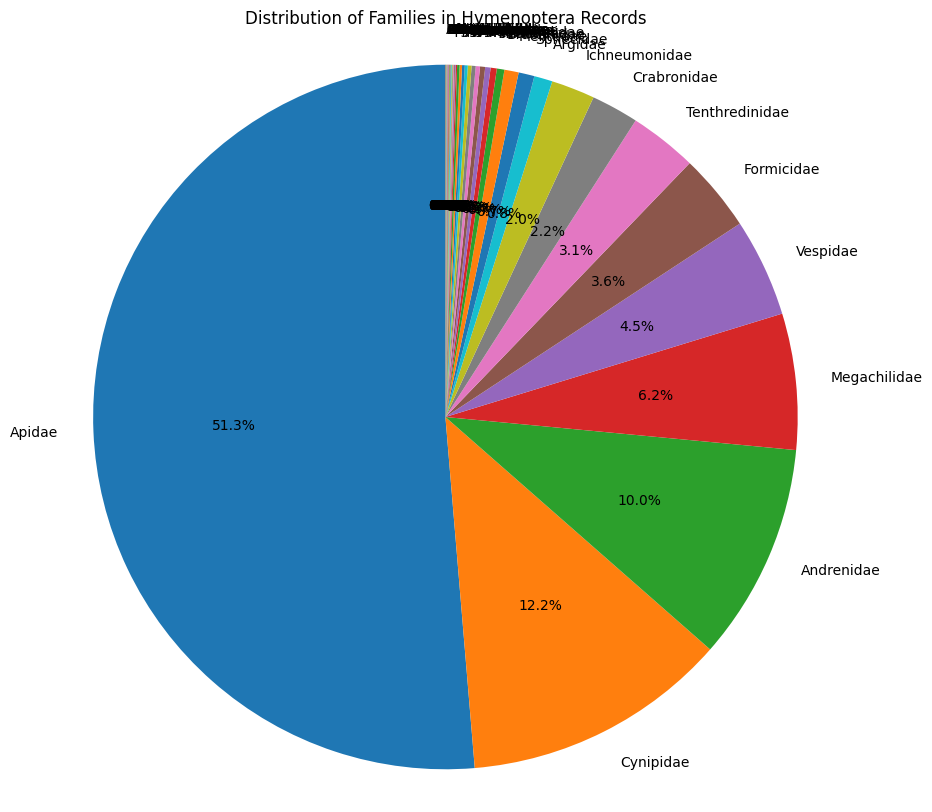

In [ ]:
import matplotlib.pyplot as plt

# Extract all families from the records
all_families = [record.get('family') for record in order_records if record.get('family')]

# Count the occurrences of each family
family_counts = pd.Series(all_families).value_counts()

# Create a pie chart
fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(family_counts, labels=family_counts.index, autopct='%1.1f%%', startangle=90)
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title('Distribution of Families in Hymenoptera Records')
plt.show()


### Part 1: Get GBIF IDs / Links

#### Species list

In [ ]:
pth = '/content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/filtered_species.csv'
species = pd.read_csv(pth)
# 1. Clean up any accidental spaces around the column names
species.columns = species.columns.str.strip()

# 2. Force the column names to be completely lowercase
species.columns = species.columns.str.lower()

#### Species IDs from GBIFs

In [ ]:
species_keys = []
species_keys_dict = {}
missing = []

for s in tqdm.tqdm(species['species'].tolist()): # Iterate over the 'species' column as a list
    result = gbifspecies.name_backbone(scientificName=s,kingdom="Animalia")
    try:
        # Check if 'usage' key exists and then if 'key' exists within 'usage'
        if 'usage' in result and 'key' in result['usage']:
            # Additionally, check if the status is 'ACCEPTED' for reliable taxon keys
            if result['usage'].get('status') == 'ACCEPTED':
                species_keys.append(result['usage']['key'])
                species_keys_dict[s] = result['usage']['key'] # Populate the dict here
            else:
                # If status is not ACCEPTED, consider it as a missing key for our purpose
                missing.append(s)
        else:
            # If 'usage' or 'key' is not found, treat it as missing
            missing.append(s)
    except Exception as e: # Catch any other unexpected errors during processing
        print(f"Error processing species '{s}': {e}")
        missing.append(s)

print(f"Species Keys found: {len(species_keys)}")
print(f"Missing species: {missing}")

100%|██████████| 20/20 [00:09<00:00,  2.06it/s]

Species Keys found: 20
Missing species: []


#### GBIF Specimen IDs and Links (Hash)

In [ ]:
all_species = []
all_tags = []
all_index = []
all_gbif_ids = []

for species in tqdm.tqdm(list(species_keys_dict.keys())):
    tags,gbifs = get_hash_ids(species,search_limit=25,example_limit=25)
    n = len(tags)
    all_species.extend([species]*n)
    all_tags.extend(tags)
    all_gbif_ids.extend(gbifs)
    all_index.extend(list(range(1,n+1)))

df_all = pd.DataFrame([all_species,all_tags,all_index,all_gbif_ids]).T
df_all = df_all.rename(columns={0:'Species',1:'gbifcode',2:'index',3:'gbifID'})
df_all.to_csv('/content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/species_gbif.csv',index=False)

100%|██████████| 21/21 [00:20<00:00,  1.03it/s]


### Part 2: Download Images

#### Load Saved Dataset
(If notebook closed and reloaded)

In [ ]:
df_loaded = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/species_gbif.csv')

df_loaded.head()

,Species,gbifcode,index,gbifID
0,Andrena flavipes,e2208023d5ed31d826dfc41538aa10a4,1,6133438788
1,Andrena flavipes,65ea81855638361b6710ab4f7384938a,2,6162767120
2,Andrena flavipes,0c42301cf8d6a08ec94df6559963c27c,3,6162796879
3,Andrena flavipes,1f4a833e7ee2eac36da518931ee8fc71,4,6163095671
4,Andrena flavipes,4b8f726e7ab945a7ba00c8a64bc01d8a,5,6169011600


#### Test download code on a small sample

In [ ]:
sample_to_test = random.sample(list(np.unique(df_loaded['Species'])),1)

In [ ]:
print(sample_to_test)

['Apis mellifera']


In [ ]:
df_sample = df_loaded #[df_loaded.Species.isin(sample_to_test)].reset_index(drop=True)

In [ ]:
import os
import shutil

path_to_save = '/content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/test_sample'

# Remove existing content in the directory to ensure a clean slate
if os.path.exists(path_to_save):
    shutil.rmtree(path_to_save)
    print(f'Removed existing directory: {path_to_save}')

# Recreate the directory
os.makedirs(path_to_save, exist_ok=True)
print(f'Recreated directory: {path_to_save}')

errors = []

# Create the directory if it doesn't exist
os.makedirs(path_to_save, exist_ok=True)

n = len(df_sample)
for i in tqdm.tqdm(range(n)):
    species_name = df_sample['Species'].iloc[i]
    gbif_id = df_sample['gbifID'].iloc[i]
    code = df_sample['gbifcode'].iloc[i]
    example_index = df_sample['index'].iloc[i] # Get the example index

    # Construct the new filename in the format "Species name index - [gbif id]"
    file_name = f"{species_name} {example_index} - {gbif_id}"

    url = get_gbif_link(gbif_id,code)
    try:
        download_image(url, file_name, path_to_save)
    except Exception as e:
        print(f"Error downloading image {file_name}: {e}")
        errors.append(i)

print("Downloaded %d and failed on %d" % (n-len(errors),len(errors)))

Removed existing directory: /content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/test_sample
Recreated directory: /content/drive/MyDrive/Colab Notebooks/Pollinator Camera Project/test_sample


100%|██████████| 506/506 [10:51<00:00,  1.29s/it]

Downloaded 506 and failed on 0


In [ ]:
def get_species_from_occurrence_id(occurrence_id):
    """
    Retrieves the species name for a given GBIF occurrence ID.
    """
    try:
        occurrence_details = occ.get(occurrence_id)
        if 'species' in occurrence_details:
            return occurrence_details['species']
        else:
            return "Species information not found for this occurrence."
    except Exception as e:
        return f"Error retrieving occurrence details: {e}"

# Example usage:
# Replace with an actual occurrence ID from your data, e.g., from df_loaded['gbifID'].iloc[0]
example_occurrence_id = df_loaded['gbifID'].iloc[0]
species_name = get_species_from_occurrence_id(example_occurrence_id)
print(f"The occurrence ID {example_occurrence_id} corresponds to the species: {species_name}")

The occurrence ID 6133438788 corresponds to the species: Andrena flavipes
